In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.pipeline import Pipeline
from recurrence_data import load_recurrence_data



In [2]:
recurrence_data = load_recurrence_data()
data = recurrence_data["data"]

X = data.drop(columns=["recurrence_status", "poiseid"])
y = data["recurrence_status"]
groups = data["poiseid"]

expression_features = recurrence_data["expression_features"]
encoded_clinical_features = recurrence_data["encoded_clinical_features"]
numeric_features = recurrence_data["numeric_features"]
metadata = recurrence_data["metadata"]

print("Samples:", len(data))
print("Features in X:", X.shape[1])
print("Expression features:", len(expression_features))
print("Encoded clinical features:", len(encoded_clinical_features))
print("Class counts:\n", y.value_counts().sort_index())
print("Unique donors:", groups.nunique())

Samples: 96
Features in X: 42561
Expression features: 42551
Encoded clinical features: 10
Class counts:
 recurrence_status
0    68
1    28
Name: count, dtype: int64
Unique donors: 44


# Whole Dataset

## Logistic Regression

LR CV ROC-AUC mean: 0.6284
LR CV ROC-AUC std: 0.1334
Classes: [0 1]
y value counts:
 recurrence_status
0    68
1    28
Name: count, dtype: int64
y_train value counts:
 recurrence_status
0    54
1    22
Name: count, dtype: int64
y_test value counts:
 recurrence_status
0    14
1     6
Name: count, dtype: int64
groups_train value counts:
 poiseid
2011    4
6027    4
6039    3
2018    3
6019    2
2048    2
2097    2
2005    2
6056    2
2002    2
2003    2
6021    2
2041    2
2060    2
6022    2
6017    2
6057    2
2065    2
6044    2
6060    2
2039    2
6035    2
6040    2
6062    2
2075    2
6045    2
6049    2
2028    2
2010    1
6043    1
2023    1
2014    1
2056    1
2006    1
6034    1
2038    1
6028    1
2031    1
2024    1
2091    1
6038    1
6023    1
Name: count, dtype: int64
groups_test value counts:
 poiseid
2074    2
6025    2
2010    1
2056    1
6038    1
2024    1
2031    1
6043    1
6034    1
6028    1
2023    1
2038    1
2006    1
2091    1
2014    1
2018    1
6045    1
602

c:\Users\sp2sh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.7
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC Score: 0.39285714285714285
Confusion Matrix:
[[14  0]
 [ 6  0]]


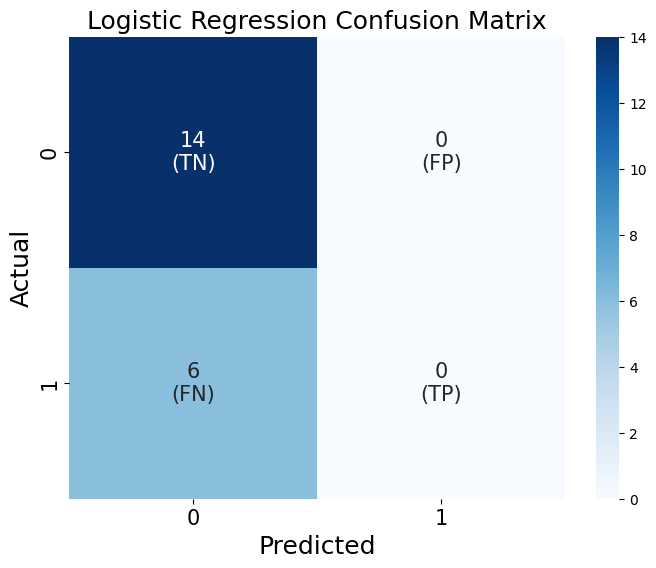

In [3]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.20, random_state=42, stratify=y)

LR_Model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

LR_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
LR_cross_scores = cross_val_score(LR_Model, X_train, y_train, cv=LR_cv, groups=groups_train, scoring='roc_auc')
print(f"LR CV ROC-AUC mean: {LR_cross_scores.mean():.4f}")
print(f"LR CV ROC-AUC std: {LR_cross_scores.std():.4f}")

# Train the model
LR_Model.fit(X_train, y_train)

print("Classes:", LR_Model.named_steps['classifier'].classes_)
print("y value counts:\n", y.value_counts())
print("y_train value counts:\n", y_train.value_counts())
print("y_test value counts:\n", y_test.value_counts())
print("groups_train value counts:\n", groups_train.value_counts())
print("groups_test value counts:\n", groups_test.value_counts())

# Predict on the test set
y_pred = LR_Model.predict(X_test)
y_pred_proba = LR_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
LR_accuracy = accuracy_score(y_test, y_pred)
LR_precision = precision_score(y_test, y_pred)
LR_recall = recall_score(y_test, y_pred)
LR_f1 = f1_score(y_test, y_pred)
LR_roc_auc = roc_auc_score(y_test, y_pred_proba)
LR_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {LR_accuracy}')
print(f'Precision: {LR_precision}')
print(f'Recall: {LR_recall}')
print(f'F1 Score: {LR_f1}')
print(f'ROC-AUC Score: {LR_roc_auc}')
print(f'Confusion Matrix:\n{LR_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_conf_matrix.shape[1])] 
                              for i in range(LR_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Random Forest

c:\Users\sp2sh\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


RF Model Cross-validation average score: 0.5795454545454546


c:\Users\sp2sh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.7
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC Score: 0.5714285714285714
Confusion Matrix:
[[14  0]
 [ 6  0]]


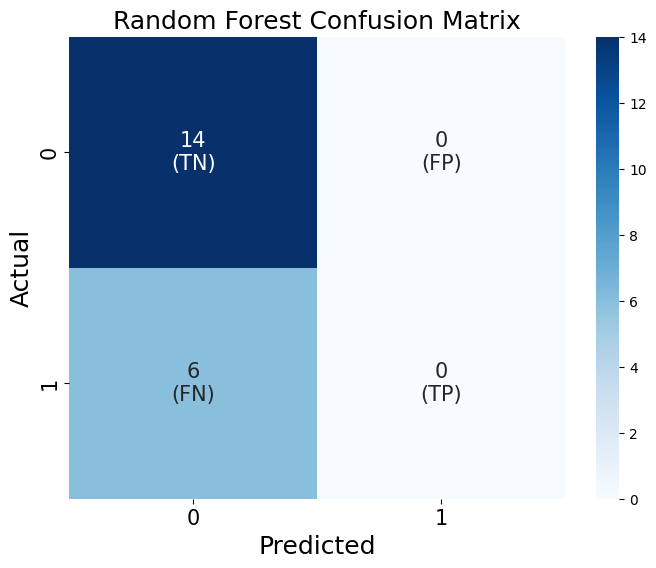

In [4]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X,y, groups, test_size=0.20, random_state=42, stratify=y)

RF_Model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

RF_cross_scores = cross_val_score(RF_Model, X_train, y_train, cv=5, groups=groups_train, scoring='roc_auc')
print(f'RF Model Cross-validation average score: {RF_cross_scores.mean()}')

# Train the model
RF_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = RF_Model.predict(X_test)
y_pred_proba = RF_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
RF_accuracy = accuracy_score(y_test, y_pred)
RF_precision = precision_score(y_test, y_pred)
RF_recall = recall_score(y_test, y_pred)
RF_f1 = f1_score(y_test, y_pred)
RF_roc_auc = roc_auc_score(y_test, y_pred_proba)
RF_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {RF_accuracy}')
print(f'Precision: {RF_precision}')
print(f'Recall: {RF_recall}')
print(f'F1 Score: {RF_f1}')
print(f'ROC-AUC Score: {RF_roc_auc}')
print(f'Confusion Matrix:\n{RF_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_conf_matrix.shape[1])] 
                              for i in range(RF_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Naive Bayes

c:\Users\sp2sh\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


NB Model Cross-validation average score: 0.5
Accuracy: 0.75
Precision: 1.0
Recall: 0.16666666666666666
F1 Score: 0.2857142857142857
ROC-AUC Score: 0.5833333333333334
Confusion Matrix:
[[14  0]
 [ 5  1]]


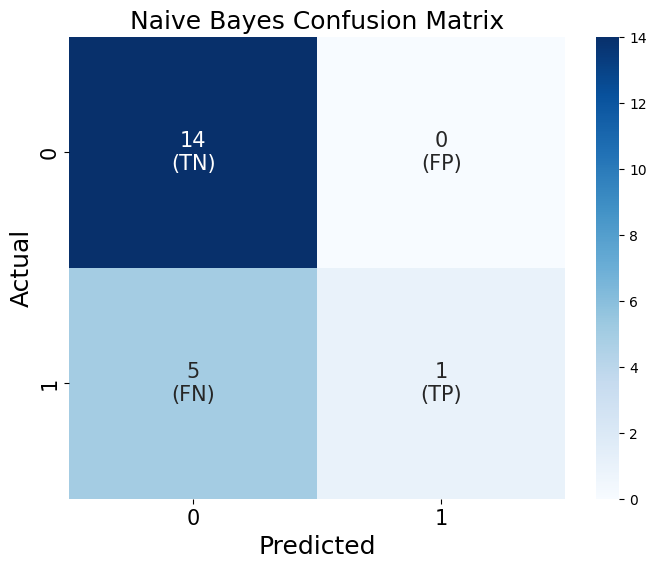

In [5]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X,y, groups, test_size=0.20, random_state=42, stratify=y)

NB_Model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', GaussianNB())
])

NB_cross_scores = cross_val_score(NB_Model, X_train, y_train, cv=5, groups=groups_train, scoring='roc_auc')
print(f'NB Model Cross-validation average score: {NB_cross_scores.mean()}')

# Train the model
NB_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = NB_Model.predict(X_test)
y_pred_proba = NB_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
NB_accuracy = accuracy_score(y_test, y_pred)
NB_precision = precision_score(y_test, y_pred)
NB_recall = recall_score(y_test, y_pred)
NB_f1 = f1_score(y_test, y_pred)
NB_roc_auc = roc_auc_score(y_test, y_pred_proba)
NB_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {NB_accuracy}')
print(f'Precision: {NB_precision}')
print(f'Recall: {NB_recall}')
print(f'F1 Score: {NB_f1}')
print(f'ROC-AUC Score: {NB_roc_auc}')
print(f'Confusion Matrix:\n{NB_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_conf_matrix.shape[1])] 
                              for i in range(NB_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Support Vector Machine

c:\Users\sp2sh\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


SVM Model Cross-validation average score: 0.4833333333333334


c:\Users\sp2sh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.7
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC Score: 0.4523809523809524
Confusion Matrix:
[[14  0]
 [ 6  0]]


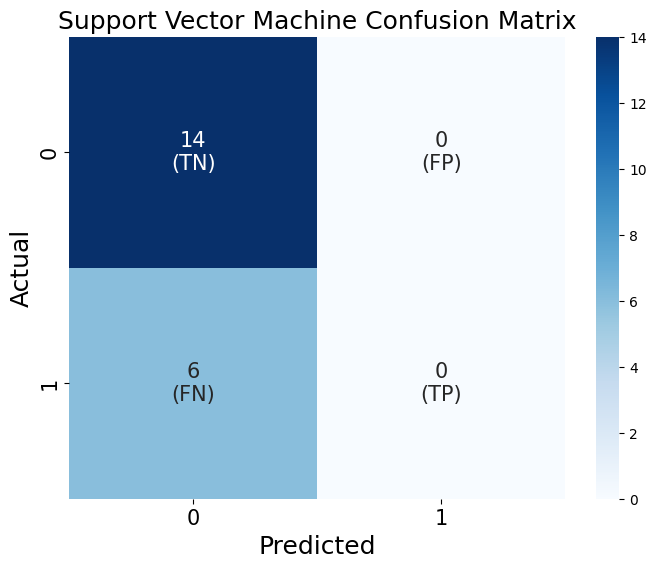

In [6]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X,y, groups, test_size=0.20, random_state=42, stratify=y)

SVM_Model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', SVC(probability=True))
])

SVM_cross_scores = cross_val_score(SVM_Model, X_train, y_train, cv=10, groups=groups_train, scoring='roc_auc')
print(f'SVM Model Cross-validation average score: {SVM_cross_scores.mean()}')

# Train the model
SVM_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = SVM_Model.predict(X_test)
y_pred_proba = SVM_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
SVM_accuracy = accuracy_score(y_test, y_pred)
SVM_precision = precision_score(y_test, y_pred)
SVM_recall = recall_score(y_test, y_pred)
SVM_f1 = f1_score(y_test, y_pred)
SVM_roc_auc = roc_auc_score(y_test, y_pred_proba)
SVM_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {SVM_accuracy}')
print(f'Precision: {SVM_precision}')
print(f'Recall: {SVM_recall}')
print(f'F1 Score: {SVM_f1}')
print(f'ROC-AUC Score: {SVM_roc_auc}')
print(f'Confusion Matrix:\n{SVM_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_conf_matrix.shape[1])] 
                              for i in range(SVM_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Data Visualization

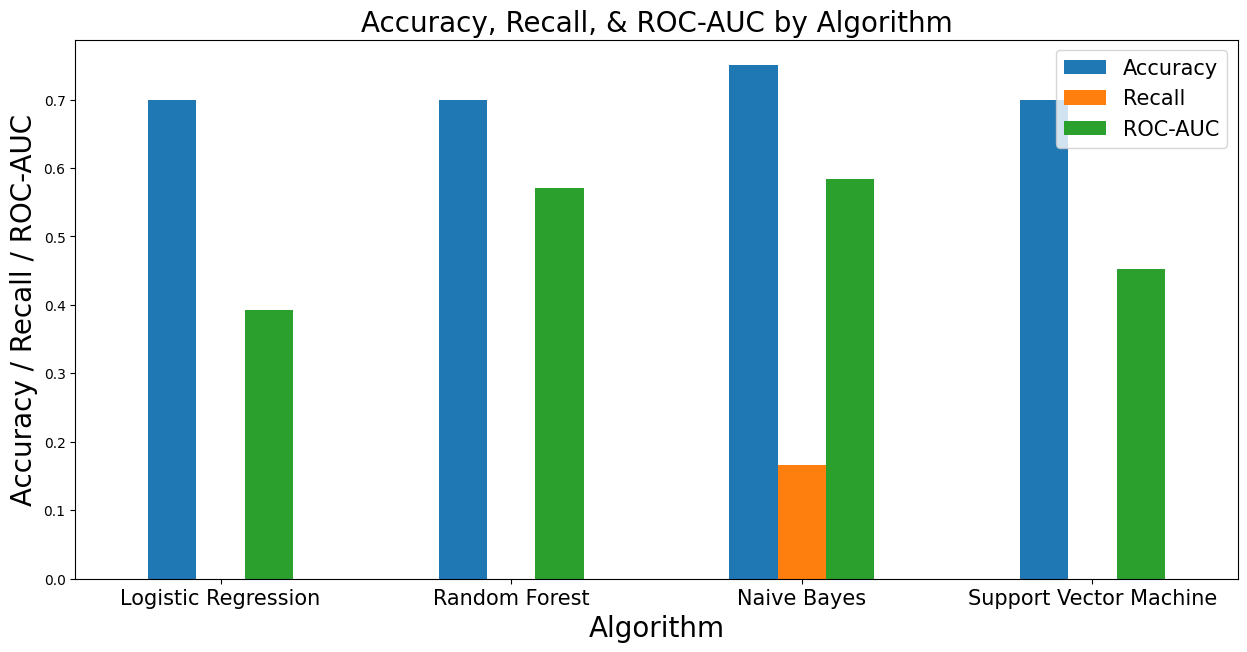

In [7]:
data = {
    "Logistic Regression": [
        LR_accuracy,
        LR_recall,
        LR_roc_auc,
    ],
    "Random Forest": [
        RF_accuracy,
        RF_recall,
        RF_roc_auc,
    ],
    "Naive Bayes": [
        NB_accuracy,
        NB_recall,
        NB_roc_auc,
    ],
    "Support Vector Machine": [
        SVM_accuracy,
        SVM_recall,
        SVM_roc_auc,
    ],
    
}

data_df = pd.DataFrame(data=data).T.reset_index()
data_df.columns = ["Algorithm", "Accuracy", "Recall", "ROC-AUC"]

# creating the bar plot
data_df.plot(kind="bar", x="Algorithm", y=["Accuracy", "Recall", "ROC-AUC"], figsize=(15, 7), rot=0)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("Accuracy / Recall / ROC-AUC", fontsize=20)
plt.title("Accuracy, Recall, & ROC-AUC by Algorithm", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)

plt.show()

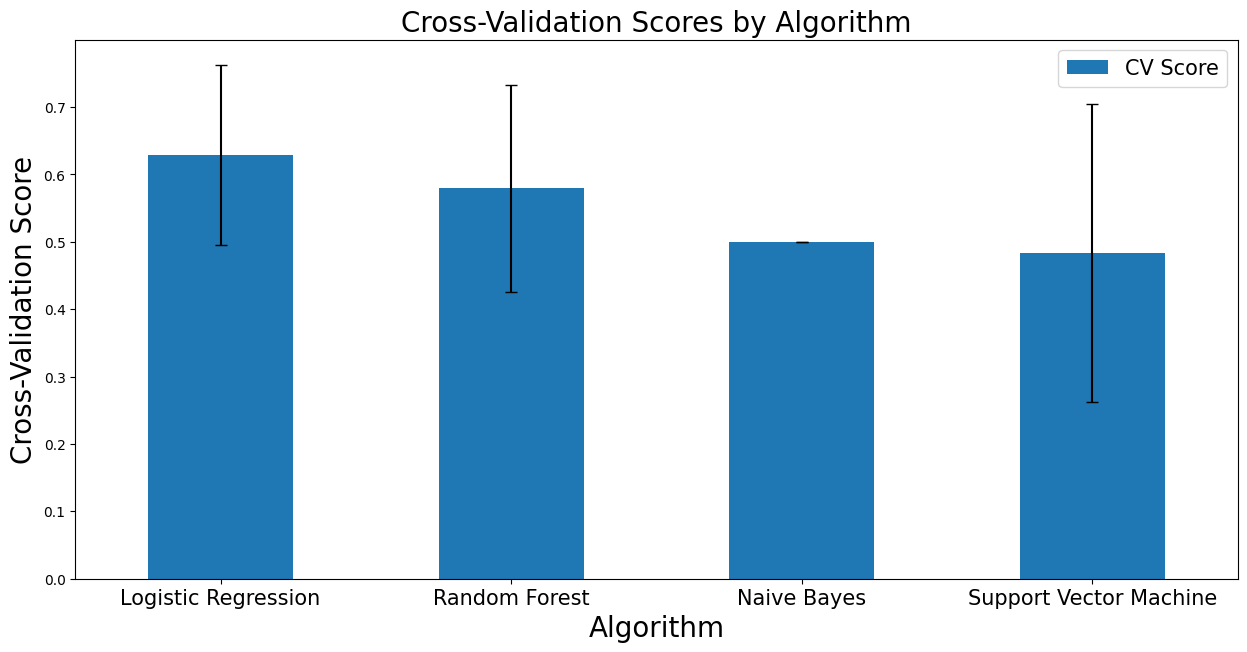

In [8]:
data = {
    "Logistic Regression": [
        LR_cross_scores.mean(),
        LR_cross_scores.std(),
    ],
    "Random Forest": [
        RF_cross_scores.mean(),
        RF_cross_scores.std(),
    ],
    "Naive Bayes": [
        NB_cross_scores.mean(),
        NB_cross_scores.std(),
    ],
    "Support Vector Machine": [
        SVM_cross_scores.mean(),
        SVM_cross_scores.std(),
    ],
}

data_df = pd.DataFrame(data=data).T.reset_index()
data_df.columns = ["Algorithm", "CV Score", "Error"]

ax = data_df.plot(
    kind="bar",
    x="Algorithm",
    y="CV Score",
    yerr="Error",
    figsize=(15, 7),
    rot=0,
    capsize=4
)

plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("Cross-Validation Score", fontsize=20)
plt.title("Cross-Validation Scores by Algorithm", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)

plt.show()